# Resnet + Bi/Tri-gram

Notebook cơ bản + các tính năng/tiền xử lý tham khảo từtừ https://www.kaggle.com/code/blamerx/s6e3-0-91925-bi-tri-gram-te-xgb

ResNet -> Mã hóa Vibe ChatGPT (với nhiều ví dụ multi - shot)

# Dự đoán tỷ lệ khách hàng rời bỏ bằng mã hóa mục tiêu Bi-gram/Tri-gram

Notebook này triển khai một pipeline học máy để dự đoán tỷ lệ khách hàng rời bỏ bằng ResNet với các kỹ thuật kỹ thuật đặc trưng nâng cao, bao gồm:
- **Đặc trưng phân loại tổng hợp Bi-gram và Tri-gram**: Ghép nối các cặp/bộ ba đặc trưng phân loại hàng đầu để nắm bắt các tương tác
- **Mã hóa mục tiêu K-fold bên trong**: Mã hóa các đặc trưng phân loại bằng cách sử dụng số liệu thống kê mục tiêu từ các fold kiểm định chéo bên trong
- **Kỹ thuật đặc trưng toàn diện**: Mã hóa tần suất, tương tác số học, số lượng dịch vụ và các đặc trưng phân phối

## Quy trình xử lý dữ liệu máy học



<b style="color: #1e40af;">Đổi mới quan trọng:</strong> <span style="color: #1e3a8a;">Mã hóa mục tiêu phân loại tổng hợp Bi-gram/Tri-gram nắm bắt được các tương tác đặc trưng 2 chiều và 3 chiều mà các mô hình dựa trên cây không thể dễ dàng học được từ các phân tách tiêu chuẩn. Ví dụ, việc kết hợp <code>Contract</code> + <code>InternetService</code> tạo ra các tính năng như "Thuê theo tháng_cáp quang" với tỷ lệ hủy dịch vụ cụ thể.</span>
</div>

---## 2. Mô tả và Tải Tập Dữ Liệu

### Nguồn Dữ Liệu
- **Tập Huấn Luyện**: Dữ liệu khách hàng được gắn nhãn để huấn luyện mô hình
- **Tập Kiểm Tra**: Dữ liệu chưa được gắn nhãn để gửi dự đoán
- **Tập Dữ Liệu Gốc**: Dữ liệu lịch sử bổ sung từ WA_Fn-UseC_-Telco-Customer-Churn.csv

### Tổng Quan Các Tính Năng
| Danh Mục | Tính Năng | Mô Tả |
|----------|----------|-------------|
| **Thông Tin Nhân Khẩu Học** | giới tính, Người Cao Tuổi, Đối Tác, Người Phụ Thuộc | Thông tin hồ sơ khách hàng |
| **Dịch Vụ** | Dịch Vụ Điện Thoại, Nhiều Đường Dây, Dịch Vụ Internet, Bảo Mật Trực Tuyến, Sao Lưu Trực Tuyến, Bảo Vệ Thiết Bị, Hỗ Trợ Kỹ Thuật, Truyền Hình Trực Tuyến, Phim Trực Tuyến | Các dịch vụ đã đăng ký |
| **Tài Khoản** | thời hạn, Hợp Đồng, Hóa Đơn Điện Tử, Phương Thức Thanh Toán, Phí Hàng Tháng, Tổng Phí | Thông tin tài khoản và hóa đơn |
| **Mục Tiêu** | Tỷ lệ khách hàng rời bỏ | Khách hàng đã rời đi chưa (Có/Không) |

In [1]:
import tensorflow as tf
import keras

2026-03-09 22:23:50.587352: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773095031.018860      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773095031.121874      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773095032.075109      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773095032.075153      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773095032.075156      24 computation_placer.cc:177] computation placer alr

In [ ]:
import numpy as np
import pandas as pd
import warnings
import gc
import time
from itertools import combinations

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import TargetEncoder
from sklearn.preprocessing import StandardScaler


import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
# Cấu hình
class CFG:
    TARGET = 'Churn'
    N_FOLDS = 20       
    INNER_FOLDS = 5   
    RANDOM_SEED = 42
    
    TRAIN_PATH = "/kaggle/input/competitions/playground-series-s6e3/train.csv"
    TEST_PATH = "/kaggle/input/competitions/playground-series-s6e3/test.csv"
    ORIGINAL_PATH = "/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Các nhóm phân loại hàng đầu cho các tổ hợp bigram/trigram (theo tầm quan trọng của đặc trưng)
TOP_CATS_FOR_NGRAM = [
    'Contract', 'InternetService', 'PaymentMethod',
    'OnlineSecurity', 'TechSupport', 'PaperlessBilling'
]

print("Configuration set!")

Configuration set!


In [ ]:
# Load dữ liệu
print("Loading datasets...")
train = pd.read_csv(CFG.TRAIN_PATH)
test = pd.read_csv(CFG.TEST_PATH)
orig = pd.read_csv(CFG.ORIGINAL_PATH)

# Encode biến mục tiêu
train[CFG.TARGET] = train[CFG.TARGET].map({'No': 0, 'Yes': 1}).astype(int)
orig[CFG.TARGET] = orig[CFG.TARGET].map({'No': 0, 'Yes': 1}).astype(int)

# Xử lý TotalCharges trong dữ liệu gốc
orig['TotalCharges'] = pd.to_numeric(orig['TotalCharges'], errors='coerce')
orig['TotalCharges'].fillna(orig['TotalCharges'].median(), inplace=True)

# Xóa ID khách hàng nếu có
if 'customerID' in orig.columns:
    orig.drop(columns=['customerID'], inplace=True)

# Lưu ID để sử dụng sau này
train_ids = train['id'].copy()
test_ids = test['id'].copy()

print(f"Train Shape : {train.shape}")
print(f"Test Shape  : {test.shape}")
print(f"Original Shape: {orig.shape}")

Loading datasets...
Train Shape : (594194, 21)
Test Shape  : (254655, 20)
Original Shape: (7043, 20)


In [ ]:
# Overview dữ liệu
print("="*60)
print("TRAINING DATA OVERVIEW")
print("="*60)
display(train.head())

print("\n" + "="*60)
print("DATA TYPES")
print("="*60)
print(train.dtypes.to_frame('dtype'))

TRAINING DATA OVERVIEW


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1



DATA TYPES
                    dtype
id                  int64
gender             object
SeniorCitizen       int64
Partner            object
Dependents         object
tenure              int64
PhoneService       object
MultipleLines      object
InternetService    object
OnlineSecurity     object
OnlineBackup       object
DeviceProtection   object
TechSupport        object
StreamingTV        object
StreamingMovies    object
Contract           object
PaperlessBilling   object
PaymentMethod      object
MonthlyCharges    float64
TotalCharges      float64
Churn               int64


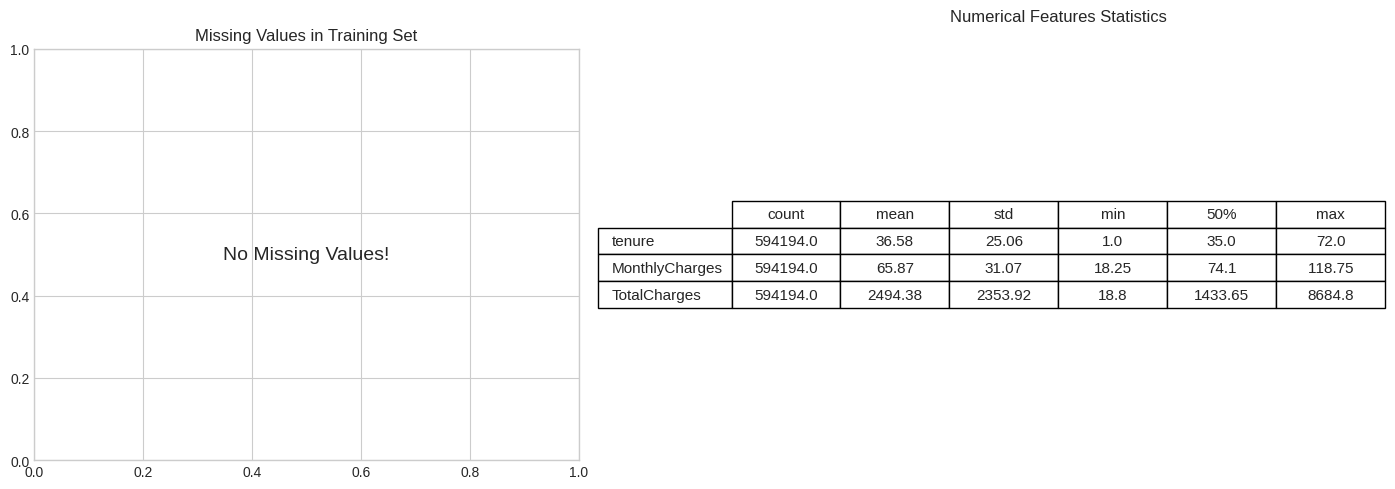

In [ ]:
# Phân tích giá trị thiếu
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Giá trị thiếu trong tập dữ liệu huấn luyện
train_missing = train.isnull().sum()
train_missing = train_missing[train_missing > 0]
if len(train_missing) > 0:
    axes[0].barh(train_missing.index, train_missing.values, color='coral')
    axes[0].set_xlabel('Missing Count')
    axes[0].set_title('Missing Values in Training Set')
else:
    axes[0].text(0.5, 0.5, 'No Missing Values!', ha='center', va='center', fontsize=14)
    axes[0].set_title('Missing Values in Training Set')

# Thống kê số liệu
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
stats_df = train[num_cols].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']]
axes[1].axis('off')
table = axes[1].table(cellText=stats_df.round(2).values,
                       rowLabels=stats_df.index,
                       colLabels=stats_df.columns,
                       cellLoc='center',
                       loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)
axes[1].set_title('Numerical Features Statistics', fontsize=12, pad=20)

plt.tight_layout()
plt.show()

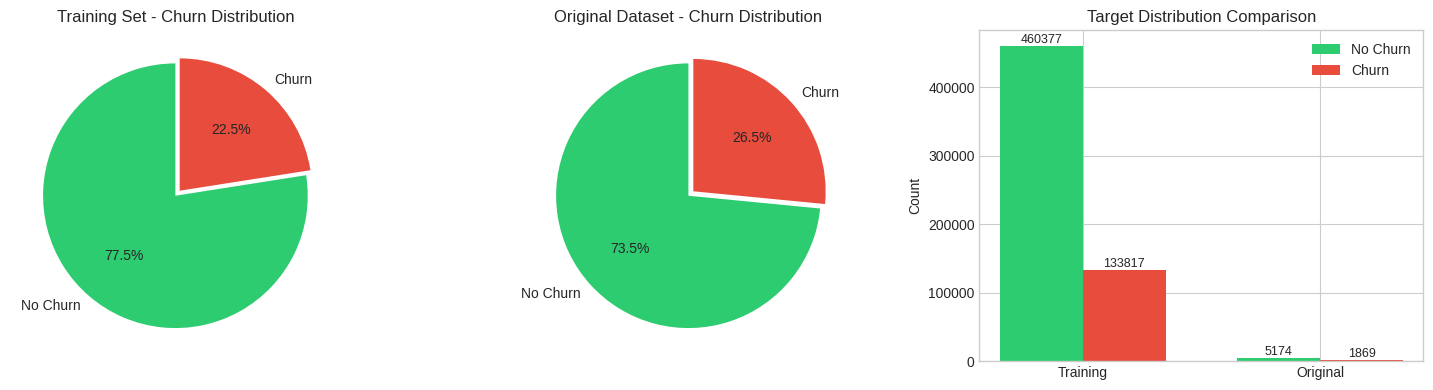


Churn Rate - Training: 22.52%
Churn Rate - Original: 26.54%


In [ ]:
# Phân phối mục tiêu
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Mục tiêu của tập huấn luyện
train_churn = train[CFG.TARGET].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(train_churn.values, labels=['No Churn', 'Churn'], autopct='%1.1f%%', 
            colors=colors, explode=[0, 0.05], startangle=90)
axes[0].set_title('Training Set - Churn Distribution')

# Mục tiêu của tập dữ liệu gốc
orig_churn = orig[CFG.TARGET].value_counts()
axes[1].pie(orig_churn.values, labels=['No Churn', 'Churn'], autopct='%1.1f%%', 
            colors=colors, explode=[0, 0.05], startangle=90)
axes[1].set_title('Original Dataset - Churn Distribution')

# Biểu đồ sánh phân phối mục tiêu
x = np.arange(2)
width = 0.35
bars1 = axes[2].bar(x - width/2, [train_churn[0], orig_churn[0]], width, label='No Churn', color='#2ecc71')
bars2 = axes[2].bar(x + width/2, [train_churn[1], orig_churn[1]], width, label='Churn', color='#e74c3c')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Training', 'Original'])
axes[2].set_ylabel('Count')
axes[2].set_title('Target Distribution Comparison')
axes[2].legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[2].annotate(f'{int(height)}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nChurn Rate - Training: {train[CFG.TARGET].mean()*100:.2f}%")
print(f"Churn Rate - Original: {orig[CFG.TARGET].mean()*100:.2f}%")

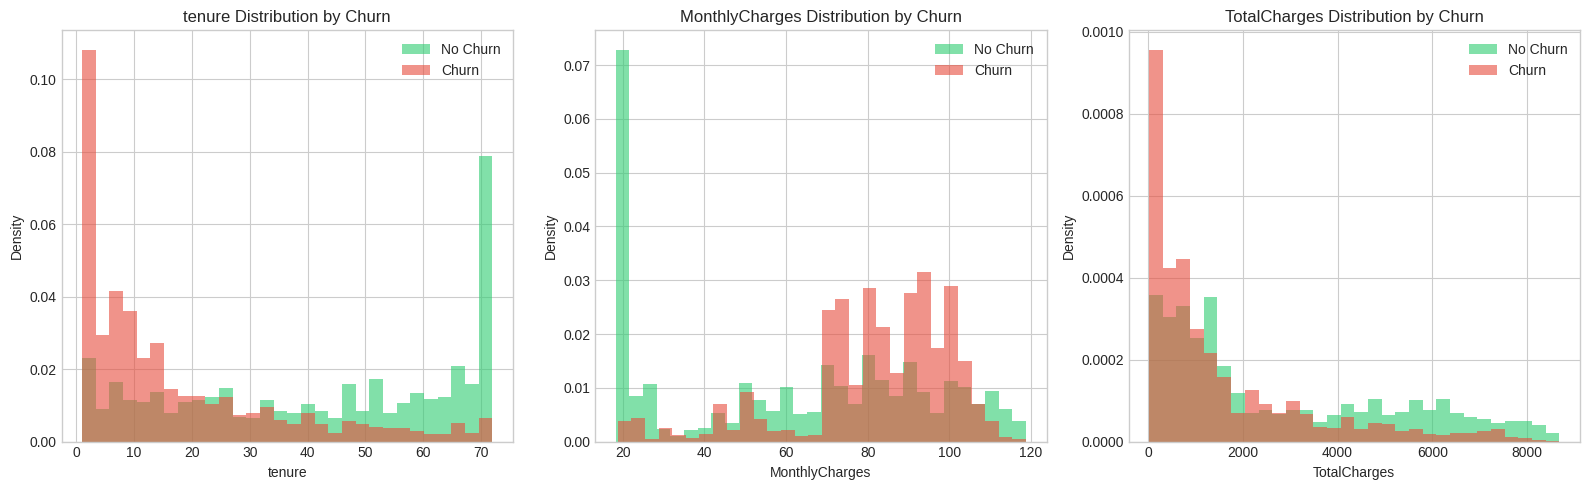


Key Observations:
  - Tenure: Churners tend to have shorter tenure
  - MonthlyCharges: Churners often have higher monthly charges
  - TotalCharges: Churners typically have lower total charges (correlated with tenure)


In [ ]:
# Phân phối số liệu theo mục tiêu
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    for churn_val, label, color in [(0, 'No Churn', '#2ecc71'), (1, 'Churn', '#e74c3c')]:
        data = train[train[CFG.TARGET] == churn_val][col]
        axes[idx].hist(data, bins=30, alpha=0.6, label=label, color=color, density=True)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Density')
    axes[idx].set_title(f'{col} Distribution by Churn')
    axes[idx].legend()

plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("  - Tenure: Churners tend to have shorter tenure")
print("  - MonthlyCharges: Churners often have higher monthly charges")
print("  - TotalCharges: Churners typically have lower total charges (correlated with tenure)")

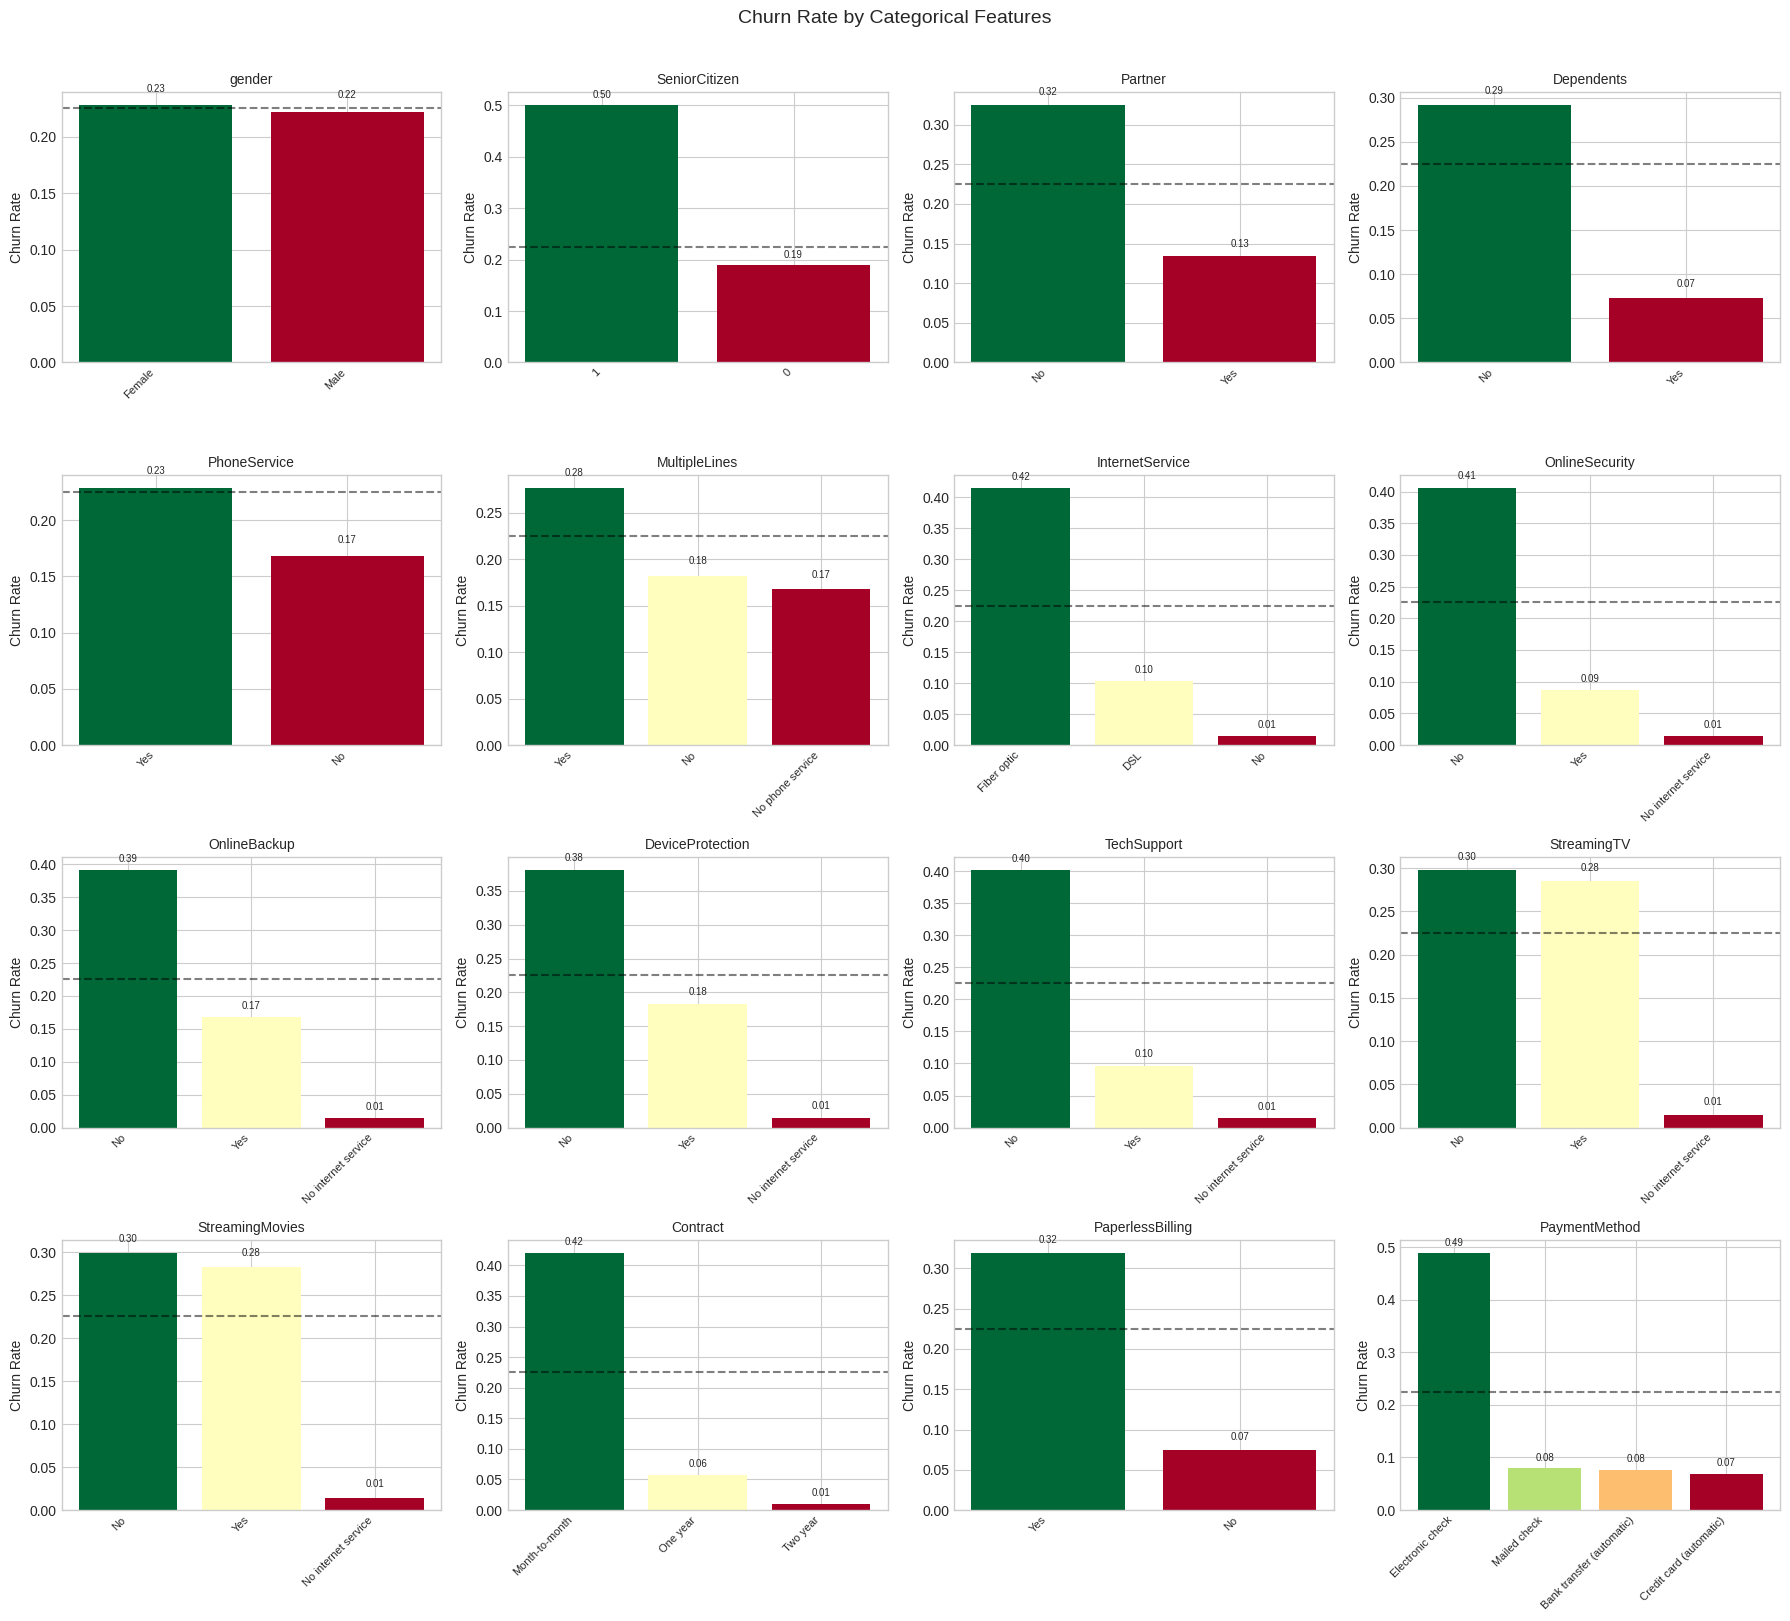

In [ ]:
# Phân tích các thuộc tính danh mục
CATS = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for idx, col in enumerate(CATS):
    # Tính tỷ lệ khách hàng rời bỏ theo từng danh mục
    churn_rate = train.groupby(col)[CFG.TARGET].mean().sort_values(ascending=False)
    
    colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(churn_rate)))
    bars = axes[idx].bar(range(len(churn_rate)), churn_rate.values, color=colors)
    axes[idx].set_xticks(range(len(churn_rate)))
    axes[idx].set_xticklabels(churn_rate.index, rotation=45, ha='right', fontsize=8)
    axes[idx].set_ylabel('Churn Rate')
    axes[idx].set_title(f'{col}', fontsize=10)
    axes[idx].axhline(y=train[CFG.TARGET].mean(), color='black', linestyle='--', alpha=0.5)
    
    # trị vào biểu đồ trị vào biểu đồ
    for bar, val in zip(bars, churn_rate.values):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                      f'{val:.2f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Churn Rate by Categorical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

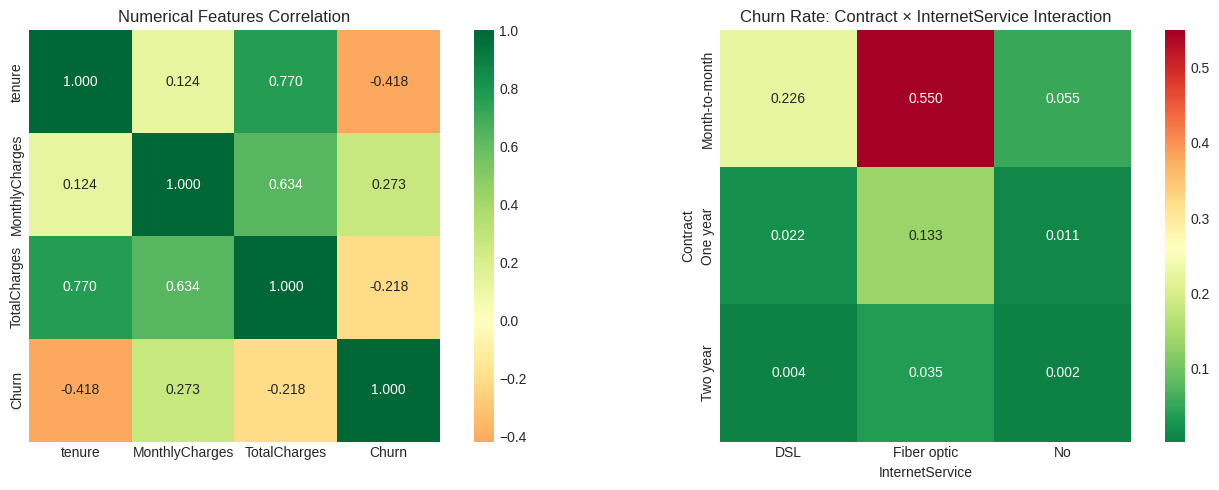


Note: strong> interaction between Contract type and InternetService!
This justifies using bi-gram/tri-gram composite features.


In [ ]:
# Ma trận tương quan cho các đặc trưng số
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tương quan số học
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr_matrix = train[num_cols + [CFG.TARGET]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, ax=axes[0], 
            fmt='.3f', square=True)
axes[0].set_title('Numerical Features Correlation')

# Tỷ lệ khách hàng rời bỏ dịch vụ hợp đồng so với dịch vụ Internet (mối tương quan quan trọng)
pivot = train.pivot_table(values=CFG.TARGET, index='Contract', 
                          columns='InternetService', aggfunc='mean')
sns.heatmap(pivot, annot=True, cmap='RdYlGn_r', center=0.26, ax=axes[1], 
            fmt='.3f', square=True)
axes[1].set_title('Churn Rate: Contract × InternetService Interaction')

plt.tight_layout()
plt.show()

print("\nNote: strong> interaction between Contract type and InternetService!")
print("This justifies using bi-gram/tri-gram composite features.")

### 3.5 Những hiểu biết chính từ EDA

<div class="alert alert-success" style="border-radius: 8px; padding: 20px; background: #ecfdf5; border: 1px solid #10b981;">

<h4 style="margin-top:0; color:#047857;">Những phát hiện chính</h4>

<ul>

<li><strong>Mất cân bằng lớp:</strong> Tập dữ liệu chứa khoảng 26% khách hàng đã rời bỏ, thể hiện sự mất cân bằng lớp ở mức độ vừa phải. Các chỉ số đánh giá như ROC-AUC được ưu tiên hơn độ chính xác.</li>

<li><strong>Loại hợp đồng:</strong> Thời hạn hợp đồng là yếu tố dự đoán tốt nhất về tỷ lệ rời bỏ. Khách hàng ký hợp đồng hàng tháng có tỷ lệ rời bỏ rất cao (~42%) so với hợp đồng hai năm (~3%).</li>

<li><strong>Thời gian gắn bó của khách hàng:</strong> Tỷ lệ rời bỏ tập trung ở những khách hàng mới. Xác suất khách hàng rời bỏ dịch vụ giảm đáng kể khi thời gian sử dụng dịch vụ tăng lên.

<li><strong>Dịch vụ Internet:</strong> Khách hàng sử dụng internet cáp quang có tỷ lệ rời bỏ dịch vụ cao hơn so với DSL hoặc khách hàng không sử dụng dịch vụ internet.</li>

<li><strong>Phương thức thanh toán:</strong> Người dùng séc điện tử có tỷ lệ rời bỏ dịch vụ cao hơn, có thể cho thấy hành vi thanh toán kém ổn định hơn.</li>

<li><strong>Sử dụng dịch vụ bổ sung:</strong> Khách hàng không sử dụng các dịch vụ bổ sung như <strong>Bảo mật trực tuyến</strong> hoặc <strong>Hỗ trợ kỹ thuật</strong> có khả năng rời bỏ dịch vụ cao hơn đáng kể.</li>

<li><strong>Mối quan hệ giữa các tính năng:</strong> Tổng chi phí có mối tương quan chặt chẽ với thời gian sử dụng dịch vụ, điều này là dễ hiểu vì tổng chi phí tích lũy theo thời gian.</li>

<li><strong>Mô hình giá cả:</strong> Chi phí hàng tháng cao hơn có liên quan đến tỷ lệ rời bỏ dịch vụ cao hơn, mặc dù hiệu ứng này một phần là do các gói đăng ký cáp quang.</li>

</ul>

</div>

## 4. Kỹ thuật Đặc trưng & Huấn luyện Mô hình

### 4.1 Quy trình Kỹ thuật Đặc trưng

Quy trình kỹ thuật đặc trưng bao gồm các thành phần sau:

| Bước | Loại Đặc trưng | Mô tả |
|------|--------------|-------------|
| 1 | Mã hóa Tần suất | Tần suất của các giá trị số trên tập huấn luyện/kiểm tra/gốc |
| 2 | Tương tác Số học | Tỷ lệ và độ lệch được suy ra |
| 3 | Số lượng Dịch vụ | Tổng hợp các đăng ký dịch vụ |
| 4 | ORIG_proba | Mã hóa mục tiêu từ tập dữ liệu gốc |
| 5 | Đặc trưng Phân phối | Thứ hạng phần trăm, điểm z so với phân phối khách hàng rời bỏ/không rời bỏ |
| 6 | Khoảng cách Lượng tử | Khoảng cách đến các lượng tử của phân phối khách hàng rời bỏ/không rời bỏ |
| 7 | N-gram Tổ hợp | **Mã hóa mục tiêu phân loại Bi-gram và Tri-gram** |

In [ ]:
# Xác định các nhóm tính năng
CATS = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]
NUMS = ['tenure', 'MonthlyCharges', 'TotalCharges']

NEW_NUMS = []
NUM_AS_CAT = []

print("Feature Engineering Pipeline Started...")
print("="*60)

Feature Engineering Pipeline Started...


In [ ]:
# 1. Mã hóa tần số
print("[1/7] Creating Frequency Encoding features...")
for col in NUMS:
    freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
    for df in [train, test, orig]:
        df[f'FREQ_{col}'] = df[col].map(freq).fillna(0).astype('float32')
    NEW_NUMS.append(f'FREQ_{col}')
print(f"    Created {len(NUMS)} frequency features")

[1/7] Creating Frequency Encoding features...
    Created 3 frequency features


In [ ]:
# 2. Tương tác số học
print("[2/7] Creating Arithmetic Interaction features...")
for df in [train, test, orig]:
    df['charges_deviation'] = (df['TotalCharges'] - df['tenure'] * df['MonthlyCharges']).astype('float32')
    df['monthly_to_total_ratio'] = (df['MonthlyCharges'] / (df['TotalCharges'] + 1)).astype('float32')
    df['avg_monthly_charges'] = (df['TotalCharges'] / (df['tenure'] + 1)).astype('float32')
NEW_NUMS += ['charges_deviation', 'monthly_to_total_ratio', 'avg_monthly_charges']
print(f"    Created 3 arithmetic features")

[2/7] Creating Arithmetic Interaction features...
    Created 3 arithmetic features


In [ ]:
# 3. Dịch vụ rất quan trọng
print("[3/7] Creating Service Count features...")
SERVICE_COLS = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for df in [train, test, orig]:
    df['service_count'] = (df[SERVICE_COLS] == 'Yes').sum(axis=1).astype('float32')
    df['has_internet'] = (df['InternetService'] != 'No').astype('float32')
    df['has_phone'] = (df['PhoneService'] == 'Yes').astype('float32')
NEW_NUMS += ['service_count', 'has_internet', 'has_phone']
print(f"    Created 3 service count features")

[3/7] Creating Service Count features...
    Created 3 service count features


In [ ]:
# 4. Ánh xạ ORIG_proba
print("[4/7] Creating ORIG_proba features (target probability from original data)...")
for col in CATS + NUMS:
    tmp = orig.groupby(col)[CFG.TARGET].mean()
    _name = f"ORIG_proba_{col}"
    train = train.merge(tmp.rename(_name), on=col, how="left")
    test = test.merge(tmp.rename(_name), on=col, how="left")
    for df in [train, test]:
        df[_name] = df[_name].fillna(0.5).astype('float32')
    NEW_NUMS.append(_name)
print(f"    Created {len(CATS + NUMS)} ORIG_proba features")

[4/7] Creating ORIG_proba features (target probability from original data)...
    Created 19 ORIG_proba features


In [16]:
# 5. Distribution Features
print("[5/7] Creating Distribution Features (percentile ranks, z-scores)...")

def pctrank_against(values, reference):
    ref_sorted = np.sort(reference)
    return (np.searchsorted(ref_sorted, values) / len(ref_sorted)).astype('float32')

def zscore_against(values, reference):
    mu, sigma = np.mean(reference), np.std(reference)
    return (np.zeros(len(values), dtype='float32') if sigma == 0 
            else ((values - mu) / sigma).astype('float32'))

orig_churner_tc    = orig.loc[orig[CFG.TARGET] == 1, 'TotalCharges'].values
orig_nonchurner_tc = orig.loc[orig[CFG.TARGET] == 0, 'TotalCharges'].values
orig_tc            = orig['TotalCharges'].values
orig_is_mc_mean    = orig.groupby('InternetService')['MonthlyCharges'].mean()

for df in [train, test]:
    tc = df['TotalCharges'].values
    df['pctrank_nonchurner_TC']  = pctrank_against(tc, orig_nonchurner_tc)
    df['pctrank_churner_TC']     = pctrank_against(tc, orig_churner_tc)
    df['pctrank_orig_TC']        = pctrank_against(tc, orig_tc)
    df['zscore_churn_gap_TC'] = (np.abs(zscore_against(tc, orig_churner_tc)) - 
                                 np.abs(zscore_against(tc, orig_nonchurner_tc))).astype('float32')
    df['zscore_nonchurner_TC'] = zscore_against(tc, orig_nonchurner_tc)
    df['pctrank_churn_gap_TC'] = (pctrank_against(tc, orig_churner_tc) - 
                                  pctrank_against(tc, orig_nonchurner_tc)).astype('float32')
    df['resid_IS_MC'] = (df['MonthlyCharges'] - df['InternetService'].map(orig_is_mc_mean).fillna(0)).astype('float32')
    
    vals = np.zeros(len(df), dtype='float32')
    for cat_val in orig['InternetService'].unique():
        mask = df['InternetService'] == cat_val
        ref = orig.loc[orig['InternetService'] == cat_val, 'TotalCharges'].values
        if len(ref) > 0 and mask.sum() > 0:
            vals[mask] = pctrank_against(df.loc[mask, 'TotalCharges'].values, ref)
    df['cond_pctrank_IS_TC'] = vals
    
    vals = np.zeros(len(df), dtype='float32')
    for cat_val in orig['Contract'].unique():
        mask = df['Contract'] == cat_val
        ref = orig.loc[orig['Contract'] == cat_val, 'TotalCharges'].values
        if len(ref) > 0 and mask.sum() > 0:
            vals[mask] = pctrank_against(df.loc[mask, 'TotalCharges'].values, ref)
    df['cond_pctrank_C_TC'] = vals

DIST_FEATURES = [
    'pctrank_nonchurner_TC', 'zscore_churn_gap_TC', 'pctrank_churn_gap_TC',
    'resid_IS_MC', 'cond_pctrank_IS_TC', 'zscore_nonchurner_TC',
    'pctrank_orig_TC', 'pctrank_churner_TC', 'cond_pctrank_C_TC'
]
NEW_NUMS += DIST_FEATURES
print(f"    Created {len(DIST_FEATURES)} distribution features")

[5/7] Creating Distribution Features (percentile ranks, z-scores)...
    Created 9 distribution features


In [ ]:
# 6. Quantile Distance Features
print("[6/7] Creating Quantile Distance Features...")
for q_label, q_val in [('q25', 0.25), ('q50', 0.50), ('q75', 0.75)]:
    ch_q = np.quantile(orig_churner_tc, q_val)
    nc_q = np.quantile(orig_nonchurner_tc, q_val)
    for df in [train, test]:
        df[f'dist_To_ch_{q_label}'] = np.abs(df['TotalCharges'] - ch_q).astype('float32')
        df[f'dist_To_nc_{q_label}'] = np.abs(df['TotalCharges'] - nc_q).astype('float32')
        df[f'qdist_gap_To_{q_label}'] = (df[f'dist_To_nc_{q_label}'] - df[f'dist_To_ch_{q_label}']).astype('float32')

QDIST_FEATURES = [
    'qdist_gap_To_q50', 'dist_To_ch_q50', 'dist_To_nc_q50',
    'dist_To_nc_q25', 'qdist_gap_To_q25',
    'dist_To_nc_q75', 'dist_To_ch_q75', 'qdist_gap_To_q75'
]
NEW_NUMS += QDIST_FEATURES
print(f"    Created {len(QDIST_FEATURES)} quantile distance features")

[6/7] Creating Quantile Distance Features...
    Created 8 quantile distance features


In [18]:
# 7. Numericals as Categories
print("[7/7] Creating Numericals-as-Categories features...")
for col in NUMS:
    _new = f'CAT_{col}'
    NUM_AS_CAT.append(_new)
    for df in [train, test]:
        df[_new] = df[col].astype(str).astype('category')
print(f"    Created {len(NUMS)} numerical-as-category features")

[7/7] Creating Numericals-as-Categories features...
    Created 3 numerical-as-category features


In [ ]:
# Tính năng số mới
DIGIT_FEATURES = [
    # Tenure
    'tenure_first_digit','tenure_last_digit','tenure_second_digit',
    'tenure_mod10','tenure_mod12','tenure_num_digits',
    'tenure_is_multiple_10','tenure_rounded_10','tenure_dev_from_round10',

    # MonthlyCharges
    'mc_first_digit','mc_last_digit','mc_second_digit',
    'mc_mod10','mc_mod100','mc_num_digits',
    'mc_is_multiple_10','mc_is_multiple_50',
    'mc_rounded_10','mc_fractional','mc_dev_from_round10',

    # TotalCharges
    'tc_first_digit','tc_last_digit','tc_second_digit',
    'tc_mod10','tc_mod100','tc_num_digits',
    'tc_is_multiple_10','tc_is_multiple_100',
    'tc_rounded_100','tc_fractional','tc_dev_from_round100',

    # Derived
    'tenure_years','tenure_months_in_year',
    'mc_per_digit','tc_per_digit'
]

for df in [train, test]:

    # Tenure digits
    t_str = df['tenure'].astype(str)
    df['tenure_first_digit'] = t_str.str[0].astype(int)
    df['tenure_last_digit'] = t_str.str[-1].astype(int)
    df['tenure_second_digit'] = t_str.apply(lambda x: int(x[1]) if len(x) > 1 else 0)

    df['tenure_mod10'] = df['tenure'] % 10
    df['tenure_mod12'] = df['tenure'] % 12
    df['tenure_num_digits'] = t_str.str.len()

    df['tenure_is_multiple_10'] = (df['tenure'] % 10 == 0).astype('float32')

    df['tenure_rounded_10'] = np.round(df['tenure']/10)*10
    df['tenure_dev_from_round10'] = abs(df['tenure'] - df['tenure_rounded_10'])

    # MonthlyCharges
    mc_str = df['MonthlyCharges'].astype(str).str.replace('.', '')

    df['mc_first_digit'] = mc_str.str[0].astype(int)
    df['mc_last_digit'] = mc_str.str[-1].astype(int)
    df['mc_second_digit'] = mc_str.apply(lambda x: int(x[1]) if len(x) > 1 else 0)

    df['mc_mod10'] = np.floor(df['MonthlyCharges']) % 10
    df['mc_mod100'] = np.floor(df['MonthlyCharges']) % 100

    df['mc_num_digits'] = np.floor(df['MonthlyCharges']).astype(int).astype(str).str.len()

    df['mc_is_multiple_10'] = (np.floor(df['MonthlyCharges']) % 10 == 0).astype('float32')
    df['mc_is_multiple_50'] = (np.floor(df['MonthlyCharges']) % 50 == 0).astype('float32')

    df['mc_rounded_10'] = np.round(df['MonthlyCharges']/10)*10
    df['mc_fractional'] = df['MonthlyCharges'] - np.floor(df['MonthlyCharges'])
    df['mc_dev_from_round10'] = abs(df['MonthlyCharges'] - df['mc_rounded_10'])

    # TotalCharges
    tc_str = df['TotalCharges'].astype(str).str.replace('.', '')

    df['tc_first_digit'] = tc_str.str[0].astype(int)
    df['tc_last_digit'] = tc_str.str[-1].astype(int)
    df['tc_second_digit'] = tc_str.apply(lambda x: int(x[1]) if len(x) > 1 else 0)

    df['tc_mod10'] = np.floor(df['TotalCharges']) % 10
    df['tc_mod100'] = np.floor(df['TotalCharges']) % 100

    df['tc_num_digits'] = np.floor(df['TotalCharges']).astype(int).astype(str).str.len()

    df['tc_is_multiple_10'] = (np.floor(df['TotalCharges']) % 10 == 0).astype('float32')
    df['tc_is_multiple_100'] = (np.floor(df['TotalCharges']) % 100 == 0).astype('float32')

    df['tc_rounded_100'] = np.round(df['TotalCharges']/100)*100
    df['tc_fractional'] = df['TotalCharges'] - np.floor(df['TotalCharges'])

    df['tc_dev_from_round100'] = abs(df['TotalCharges'] - df['tc_rounded_100'])

    # Derived
    df['tenure_years'] = df['tenure'] // 12
    df['tenure_months_in_year'] = df['tenure'] % 12

    df['mc_per_digit'] = df['MonthlyCharges']/(df['mc_num_digits']+0.001)
    df['tc_per_digit'] = df['TotalCharges']/(df['tc_num_digits']+0.001)

NEW_NUMS += DIGIT_FEATURES
print(f"    Created {len(DIGIT_FEATURES)} digital Numerical features")

    Created 35 digital Numerical features


In [ ]:
# Tạo các đặc điểm phân loại tổng hợp Bigram và Trigram
print("\n" + "="*60)
print("Creating Bi-gram / Tri-gram Composite Features...")
print("="*60)

BIGRAM_COLS = []
TRIGRAM_COLS = []

# Bi-gram: tất cả các cặp từ 6 CATCAT hàng đầu = C(6,2) = 15 cặp
print(f"\nCreating Bi-gram features from top {len(TOP_CATS_FOR_NGRAM)} categoricals:")
print(f"  Columns: {TOP_CATS_FOR_NGRAM}")
for c1, c2 in combinations(TOP_CATS_FOR_NGRAM, 2):
    col_name = f"BG_{c1}_{c2}"
    for df in [train, test]:
        df[col_name] = (df[c1].astype(str) + "_" + df[c2].astype(str)).astype('category')
    BIGRAM_COLS.append(col_name)

print(f"  Created {len(BIGRAM_COLS)} bi-gram features")

# Tam giác: chỉ 4 CAT hàng đầu để giới hạn = C(4,3) = 4 bộ ba
TOP4 = TOP_CATS_FOR_NGRAM[:4]
print(f"\nCreating Tri-gram features from top 4 categoricals:")
print(f"  Columns: {TOP4}")
for c1, c2, c3 in combinations(TOP4, 3):
    col_name = f"TG_{c1}_{c2}_{c3}"
    for df in [train, test]:
        df[col_name] = (df[c1].astype(str) + "_" + df[c2].astype(str) + "_" + df[c3].astype(str)).astype('category')
    TRIGRAM_COLS.append(col_name)

print(f"  Created {len(TRIGRAM_COLS)} tri-gram features")

NGRAM_COLS = BIGRAM_COLS + TRIGRAM_COLS
print(f"\nTotal N-gram features: {len(NGRAM_COLS)}")


Creating Bi-gram / Tri-gram Composite Features...

Creating Bi-gram features from top 6 categoricals:
  Columns: ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity', 'TechSupport', 'PaperlessBilling']
  Created 15 bi-gram features

Creating Tri-gram features from top 4 categoricals:
  Columns: ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity']
  Created 4 tri-gram features

Total N-gram features: 19


In [21]:
# Feature Summary
FEATURES = NUMS + CATS + NEW_NUMS + NUM_AS_CAT + NGRAM_COLS
TE_COLUMNS = NUM_AS_CAT + CATS
TE_NGRAM_COLUMNS = NGRAM_COLS
TO_REMOVE = NUM_AS_CAT + CATS + NGRAM_COLS
STATS = ['std', 'min', 'max']

print("\n" + "="*60)
print("FEATURE ENGINEERING COMPLETE")
print("="*60)
print(f"Total Features: {len(FEATURES)}")
print(f"  - Numerical:          {len(NUMS)}")
print(f"  - Categorical:        {len(CATS)}")
print(f"  - Engineered Numerical: {len(NEW_NUMS)}")
print(f"  - Num-as-Cat:         {len(NUM_AS_CAT)}")
print(f"  - Bi-gram:            {len(BIGRAM_COLS)}")
print(f"  - Tri-gram:           {len(TRIGRAM_COLS)}")


FEATURE ENGINEERING COMPLETE
Total Features: 121
  - Numerical:          3
  - Categorical:        16
  - Engineered Numerical: 80
  - Num-as-Cat:         3
  - Bi-gram:            15
  - Tri-gram:           4


# ResNet Definition

In [22]:

# ============================================================
# MODEL
# ============================================================
def residual_block(x, dim, dropout=0.3):
    skip = x

    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dense(dim)(x)
    x = keras.layers.Activation("relu")(x)
    x = keras.layers.Dropout(dropout)(x)

    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dense(dim)(x)
    x = keras.layers.Dropout(dropout)(x)

    x = keras.layers.Add()([skip, x])
    x = keras.layers.Activation("relu")(x)
    return x

def build_resnet_model(
    input_dim,
    hidden_dim=128,
    num_blocks=3,
    dropout=0.3,
    lr=3e-4,
    weight_decay=1e-4,
):
    inp = keras.Input(shape=(input_dim,), name="features", dtype="float32")

    x = keras.layers.BatchNormalization()(inp)
    x = keras.layers.Dense(hidden_dim)(x)
    x = keras.layers.Activation("relu")(x)
    x = keras.layers.Dropout(dropout)(x)

    for _ in range(num_blocks):
        x = residual_block(x, hidden_dim, dropout=dropout)

    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dense(hidden_dim // 2)(x)
    x = keras.layers.Activation("relu")(x)
    x = keras.layers.Dropout(dropout)(x)

    out = keras.layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=keras.optimizers.AdamW(
            learning_rate=lr,
            weight_decay=weight_decay
        ),
        loss=keras.losses.BinaryCrossentropy(label_smoothing=0.01),
        metrics=[keras.metrics.AUC(name="auc")]
    )
    return model

In [23]:
BATCH_SIZE = 4096
EPOCHS = 200

In [ ]:
# Huấn luyện mô hình với phương pháp kiểm chứng chéo 10 lần
print("\n" + "="*60)
print(f"TRAINING RESNET WITH {CFG.N_FOLDS}-FOLD CROSS-VALIDATION")
print("="*60)

np.random.seed(CFG.RANDOM_SEED)
skf_outer = StratifiedKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.RANDOM_SEED)
skf_inner = StratifiedKFold(n_splits=CFG.INNER_FOLDS, shuffle=True, random_state=CFG.RANDOM_SEED)

resnet_oof = np.zeros(len(train))
resnet_pred = np.zeros(len(test))
resnet_fold_scores = []

t0 = time.time()

for i, (train_idx, val_idx) in enumerate(skf_outer.split(train, train[CFG.TARGET])):
    print(f"\n{'='*50}")
    print(f"Fold {i+1}/{CFG.N_FOLDS}")
    print(f"{'='*50}")
    
    X_tr  = train.loc[train_idx, FEATURES + [CFG.TARGET]].reset_index(drop=True).copy()
    y_tr  = train.loc[train_idx, CFG.TARGET].values
    X_val = train.loc[val_idx, FEATURES].reset_index(drop=True).copy()
    y_val = train.loc[val_idx, CFG.TARGET].values
    X_te  = test[FEATURES].reset_index(drop=True).copy()
    
    # ─── KFold TE bên trong dành cho các phân loại GỐC ────────────────────────
    for j, (in_tr, in_va) in enumerate(skf_inner.split(X_tr, y_tr)):
        X_tr2 = X_tr.loc[in_tr, FEATURES + [CFG.TARGET]].copy()
        X_va2 = X_tr.loc[in_va, FEATURES].copy()
        for col in TE_COLUMNS:
            tmp = X_tr2.groupby(col, observed=False)[CFG.TARGET].agg(STATS)
            tmp.columns = [f"TE1_{col}_{s}" for s in STATS]
            X_va2 = X_va2.merge(tmp, on=col, how="left")
            for c in tmp.columns:
                X_tr.loc[in_va, c] = X_va2[c].values.astype("float32")
                
    # Thống kê TE toàn diện cho val/test (CATCAT gốc)
    for col in TE_COLUMNS:
        tmp = X_tr.groupby(col, observed=False)[CFG.TARGET].agg(STATS)
        tmp.columns = [f"TE1_{col}_{s}" for s in STATS]
        tmp = tmp.astype("float32")
        X_val = X_val.merge(tmp, on=col, how="left")
        X_te  = X_te.merge(tmp, on=col, how="left")
        for c in tmp.columns:
            for df in [X_tr, X_val, X_te]:
                df[c] = df[c].fillna(0)
                
    # ─── KFold TE cho các phân loại N-gram ───────────────────────────
    for j, (in_tr, in_va) in enumerate(skf_inner.split(X_tr, y_tr)):
        X_tr2 = X_tr.loc[in_tr].copy()
        X_va2 = X_tr.loc[in_va].copy()
        for col in TE_NGRAM_COLUMNS:
            ng_te = X_tr2.groupby(col, observed=False)[CFG.TARGET].mean()
            ng_name = f"TE_ng_{col}"
            mapped = X_va2[col].astype(str).map(ng_te)
            X_tr.loc[in_va, ng_name] = pd.to_numeric(mapped, errors='coerce').fillna(0.5).astype('float32').values
    
    # TE gấp đầy đủ cho n-gram trên tập dữ liệu xác thực/kiểm tra
    for col in TE_NGRAM_COLUMNS:
        ng_te = X_tr.groupby(col, observed=False)[CFG.TARGET].mean()
        ng_name = f"TE_ng_{col}"
        X_val[ng_name] = pd.to_numeric(X_val[col].astype(str).map(ng_te), errors='coerce').fillna(0.5).astype('float32')
        X_te[ng_name]  = pd.to_numeric(X_te[col].astype(str).map(ng_te), errors='coerce').fillna(0.5).astype('float32')
        if ng_name in X_tr.columns:
            X_tr[ng_name] = pd.to_numeric(X_tr[ng_name], errors='coerce').fillna(0.5).astype('float32')
        else:
            X_tr[ng_name] = 0.5
                
    # sklearn TargetEncoder (Mean) cho CAT gốc
    TE_MEAN_COLS = [f'TE_{col}' for col in TE_COLUMNS]
    te = TargetEncoder(cv=CFG.INNER_FOLDS, shuffle=True, smooth='auto', target_type='binary', random_state=CFG.RANDOM_SEED)
    X_tr[TE_MEAN_COLS] = te.fit_transform(X_tr[TE_COLUMNS], y_tr)
    X_val[TE_MEAN_COLS] = te.transform(X_val[TE_COLUMNS])
    X_te[TE_MEAN_COLS] = te.transform(X_te[TE_COLUMNS])
    
    # Prepare for resnet — xóa các đặc điểm gốc
    for df in [X_tr, X_val, X_te]:
        for c in CATS + NUM_AS_CAT:
            if c in df.columns:
                df[c] = df[c].astype(str).astype("category")
        df.drop(columns=[c for c in TO_REMOVE if c in df.columns], inplace=True, errors='ignore')
    X_tr.drop(columns=[CFG.TARGET], inplace=True, errors='ignore')
    COLS_RESNET = X_tr.columns
    
    if i == 0:
        n_feats = len(COLS_RESNET)
        n_ngram_feats = sum(1 for c in COLS_RESNET if c.startswith('TE_ng_'))
        print(f"\n  Features for RESNET: {n_feats} ({n_ngram_feats} from n-gram TE)")
    
    # Train model
    # model = xgb.XGBClassifier(**XGB_PARAMS)
    # model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=1000)

    # Tỷ lệ các tính năng TE
    # Tỷ lệ các tính năng số
    scaler = StandardScaler()
    Xt = scaler.fit_transform(X_tr.values).astype(np.float32)
    Xv = scaler.transform(X_val.values).astype(np.float32)
    Xtf = scaler.transform(X_te.values).astype(np.float32)

    model = build_resnet_model(
        input_dim=Xt.shape[1],
        hidden_dim=128,
        num_blocks=3,
        dropout=0.3,
        lr=3e-4,
        weight_decay=1e-4,
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_auc",
            mode="max",
            factor=0.5,
            patience=3,
            min_lr=1e-5,
            verbose=1
        )
    ]

    model.fit(
        Xt,
        y_tr,
        validation_data=(Xv, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        callbacks=callbacks,
        verbose=2
    )
    # Ghi lại kết quả dự đoán
    resnet_oof[val_idx] = model.predict(
        Xv,
        batch_size=BATCH_SIZE,
        verbose=0
    ).ravel()
    
    fold_auc = roc_auc_score(y_val, resnet_oof[val_idx])
    resnet_fold_scores.append(fold_auc)
    
    fold_test_p = model.predict(
        Xtf,
        batch_size=BATCH_SIZE,
        verbose=0
    ).ravel()
    
    resnet_pred += fold_test_p / CFG.N_FOLDS
    
    print(f"   Fold {i+1} AUC: {fold_auc:.5f} | Time: {(time.time()-t0)/60:.1f} min")
    
    del X_tr, X_val, X_te, y_tr, y_val, model
    gc.collect()

print(f"\n{'='*60}")
print("TRAINING COMPLETE!")
print(f"{'='*60}")


TRAINING RESNET WITH 20-FOLD CROSS-VALIDATION

Fold 1/20

  Features for RESNET: 178 (19 from n-gram TE)


I0000 00:00:1773095143.155280      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773095143.161029      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/200


I0000 00:00:1773095151.351056      71 service.cc:152] XLA service 0x7e638c02be20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773095151.351113      71 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773095151.351120      71 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773095152.546489      71 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1773095159.565599      71 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


138/138 - 24s - 177ms/step - auc: 0.8366 - loss: 0.4659 - val_auc: 0.9072 - val_loss: 0.3362 - learning_rate: 3.0000e-04
Epoch 2/200
138/138 - 1s - 8ms/step - auc: 0.8963 - loss: 0.3434 - val_auc: 0.9109 - val_loss: 0.3343 - learning_rate: 3.0000e-04
Epoch 3/200
138/138 - 1s - 8ms/step - auc: 0.9024 - loss: 0.3345 - val_auc: 0.9130 - val_loss: 0.3301 - learning_rate: 3.0000e-04
Epoch 4/200
138/138 - 1s - 8ms/step - auc: 0.9056 - loss: 0.3295 - val_auc: 0.9141 - val_loss: 0.3291 - learning_rate: 3.0000e-04
Epoch 5/200
138/138 - 1s - 8ms/step - auc: 0.9073 - loss: 0.3264 - val_auc: 0.9146 - val_loss: 0.3269 - learning_rate: 3.0000e-04
Epoch 6/200
138/138 - 1s - 8ms/step - auc: 0.9089 - loss: 0.3240 - val_auc: 0.9151 - val_loss: 0.3246 - learning_rate: 3.0000e-04
Epoch 7/200
138/138 - 1s - 8ms/step - auc: 0.9095 - loss: 0.3226 - val_auc: 0.9154 - val_loss: 0.3237 - learning_rate: 3.0000e-04
Epoch 8/200
138/138 - 1s - 8ms/step - auc: 0.9102 - loss: 0.3215 - val_auc: 0.9157 - val_loss: 0.31

In [ ]:
# Tính toán các chỉ số tổng thể
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, classification_report

overall_auc = roc_auc_score(train[CFG.TARGET], resnet_oof)
mean_score = np.mean(resnet_fold_scores)
std_score = np.std(resnet_fold_scores)

print("="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
print(f"\nOverall CV AUC:  {overall_auc:.5f}")
print(f"Mean Fold AUC:   {mean_score:.5f} +/- {std_score:.5f}")
print(f"\nPer-Fold Scores:")
for i, score in enumerate(resnet_fold_scores):
    print(f"  Fold {i+1:2d}: {score:.5f}")

MODEL PERFORMANCE SUMMARY

Overall CV AUC:  0.91692
Mean Fold AUC:   0.91700 +/- 0.00186

Per-Fold Scores:
  Fold  1: 0.91829
  Fold  2: 0.91679
  Fold  3: 0.91624
  Fold  4: 0.91659
  Fold  5: 0.92122
  Fold  6: 0.91686
  Fold  7: 0.91430
  Fold  8: 0.91869
  Fold  9: 0.91657
  Fold 10: 0.91616
  Fold 11: 0.91615
  Fold 12: 0.91792
  Fold 13: 0.91960
  Fold 14: 0.91794
  Fold 15: 0.91484
  Fold 16: 0.91981
  Fold 17: 0.91676
  Fold 18: 0.91602
  Fold 19: 0.91602
  Fold 20: 0.91320


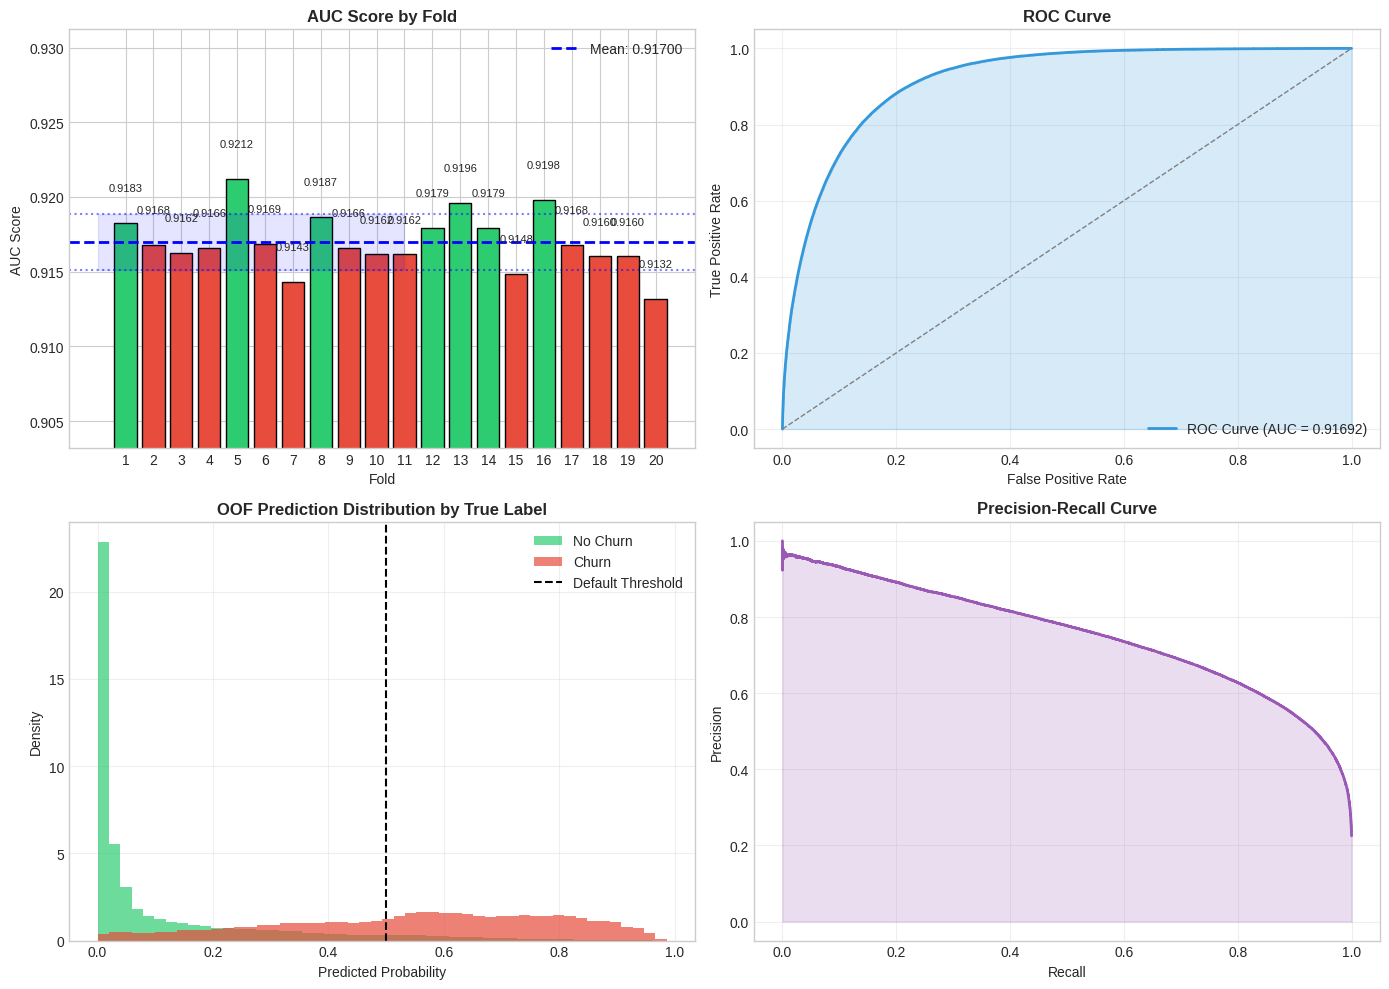

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Fold AUC Scores
ax1 = axes[0, 0]
colors = ['#2ecc71' if s >= mean_score else '#e74c3c' for s in resnet_fold_scores]
bars = ax1.bar(range(1, CFG.N_FOLDS + 1), resnet_fold_scores, color=colors, edgecolor='black')
ax1.axhline(y=mean_score, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_score:.5f}')
ax1.axhline(y=mean_score + std_score, color='blue', linestyle=':', alpha=0.5)
ax1.axhline(y=mean_score - std_score, color='blue', linestyle=':', alpha=0.5)
ax1.fill_between(range(0, 12), mean_score - std_score, mean_score + std_score, alpha=0.1, color='blue')
ax1.set_xlabel('Fold')
ax1.set_ylabel('AUC Score')
ax1.set_title('AUC Score by Fold', fontsize=12, fontweight='bold')
ax1.set_xticks(range(1, CFG.N_FOLDS + 1))
ax1.legend()
ax1.set_ylim([min(resnet_fold_scores) - 0.01, max(resnet_fold_scores) + 0.01])

for bar, score in zip(bars, resnet_fold_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
            f'{score:.4f}', ha='center', va='bottom', fontsize=8)

# 2. ROC Curve
ax2 = axes[0, 1]
fpr, tpr, thresholds = roc_curve(train[CFG.TARGET], resnet_oof)
roc_auc = auc(fpr, tpr)
ax2.plot(fpr, tpr, color='#3498db', linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.5f})')
ax2.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1)
ax2.fill_between(fpr, tpr, alpha=0.2, color='#3498db')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

# 3. Prediction Distribution
ax3 = axes[1, 0]
ax3.hist(resnet_oof[train[CFG.TARGET] == 0], bins=50, alpha=0.7, label='No Churn', color='#2ecc71', density=True)
ax3.hist(resnet_oof[train[CFG.TARGET] == 1], bins=50, alpha=0.7, label='Churn', color='#e74c3c', density=True)
ax3.axvline(x=0.5, color='black', linestyle='--', label='Default Threshold')
ax3.set_xlabel('Predicted Probability')
ax3.set_ylabel('Density')
ax3.set_title('OOF Prediction Distribution by True Label', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Precision-Recall Curve
ax4 = axes[1, 1]
precision, recall, _ = precision_recall_curve(train[CFG.TARGET], resnet_oof)
ax4.plot(recall, precision, color='#9b59b6', linewidth=2)
ax4.fill_between(recall, precision, alpha=0.2, color='#9b59b6')
ax4.set_xlabel('Recall')
ax4.set_ylabel('Precision')
ax4.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

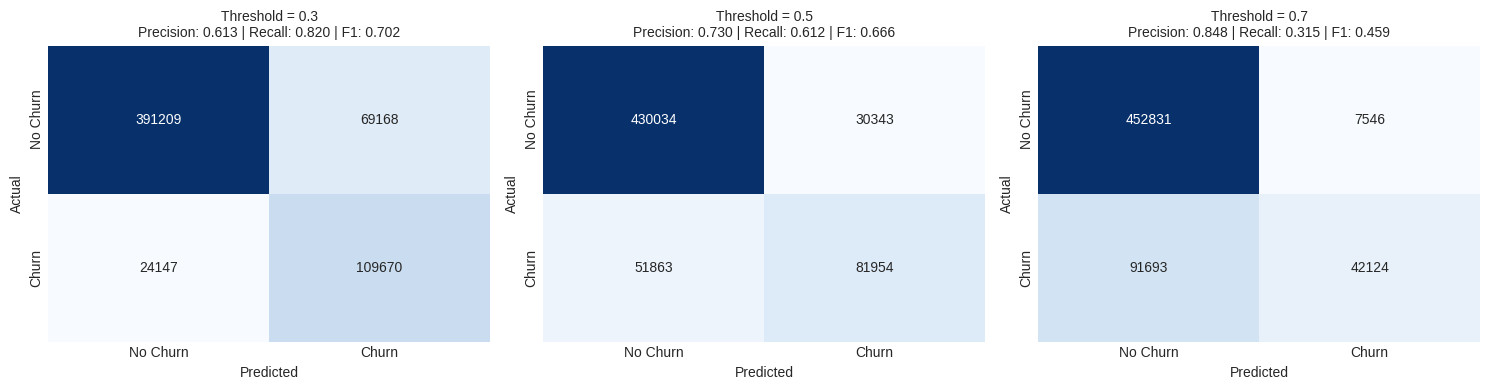


Note: Lower threshold = higher recall (catch more churners)
      Higher threshold = higher precision (more confident predictions)


In [ ]:
# Ma trận nhầm lẫn ở các ngưỡng khác nhau
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
thresholds = [0.3, 0.5, 0.7]

for ax, thresh in zip(axes, thresholds):
    y_pred = (resnet_oof >= thresh).astype(int)
    cm = confusion_matrix(train[CFG.TARGET], y_pred)
    
    # Tính toán các chỉ số
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Threshold = {thresh}\nPrecision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}', 
                fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nNote: Lower threshold = higher recall (catch more churners)")
print("      Higher threshold = higher precision (more confident predictions)")

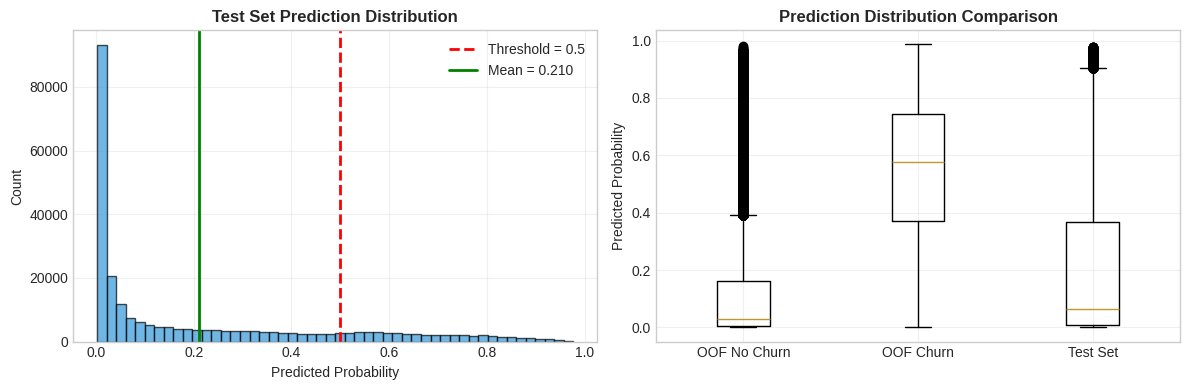


Test Set Statistics:
  Mean prediction: 0.2098
  Std prediction:  0.2594
  Min prediction:  0.0021
  Max prediction:  0.9772
  Predicted churn rate (threshold=0.5): 18.08%


In [ ]:
# Phân phối dự đoán của tập dữ liệu kiểm thử
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(resnet_pred, bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Threshold = 0.5')
axes[0].axvline(x=np.mean(resnet_pred), color='green', linestyle='-', linewidth=2, label=f'Mean = {np.mean(resnet_pred):.3f}')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')
axes[0].set_title('Test Set Prediction Distribution', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot comparison
axes[1].boxplot([resnet_oof[train[CFG.TARGET] == 0], resnet_oof[train[CFG.TARGET] == 1], resnet_pred],
               labels=['OOF No Churn', 'OOF Churn', 'Test Set'])
axes[1].set_ylabel('Predicted Probability')
axes[1].set_title('Prediction Distribution Comparison', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTest Set Statistics:")
print(f"  Mean prediction: {np.mean(resnet_pred):.4f}")
print(f"  Std prediction:  {np.std(resnet_pred):.4f}")
print(f"  Min prediction:  {np.min(resnet_pred):.4f}")
print(f"  Max prediction:  {np.max(resnet_pred):.4f}")
print(f"  Predicted churn rate (threshold=0.5): {(resnet_pred >= 0.5).mean()*100:.2f}%")

In [ ]:
# Save O Lưu dự đoán OOF vào t
oof_df = pd.DataFrame({
    'id': train_ids,
    CFG.TARGET: resnet_oof
})
oof_df.to_csv('oof_predictions.csv', index=False)
print(f"OOF predictions saved to 'oof_predictions.csv'")
print(f"  Shape: {oof_df.shape}")
display(oof_df.head())

#  Lưu dự đoán kiểm thử vào tệp nộp bài
sub_df = pd.DataFrame({
    'id': test_ids,
    CFG.TARGET: resnet_pred
})
sub_df.to_csv('submission.csv', index=False)
print(f"\nSubmission saved to 'submission.csv'")
print(f"  Shape: {sub_df.shape}")
display(sub_df.head())

OOF predictions saved to 'oof_predictions.csv'
  Shape: (594194, 2)


,id,Churn
0,0,0.008484
1,1,0.004544
2,2,0.321756
3,3,0.828318
4,4,0.789626



Submission saved to 'submission.csv'
  Shape: (254655, 2)


,id,Churn
0,594194,0.153816
1,594195,0.003200
2,594196,0.124996
3,594197,0.005750
4,594198,0.486320


### Các yếu tố thành công chính

<div class="alert alert-success" style="border-radius: 8px; padding: 20px; margin: 15px 0; background: #ecfdf5; border: 1px solid #10b981;">

<h4 style="margin-top: 0; color: #047857;">Điều gì đã làm nên hiệu quả của giải pháp này</h4>

<ul style="color: #065f46; margin-bottom: 0;">

<li><strong>Mã hóa Bi-gram/Tri-gram:</strong> Ghi nhận tương tác phân loại 2 chiều và 3 chiều</li>

<li><strong>Kỹ thuật đặc trưng toàn diện:</strong> Quy trình 7 bước tạo ra các tín hiệu dự đoán đa dạng</li>

<li><strong>Xác thực mạnh mẽ:</strong> Kiểm định chéo phân tầng 10 lần với kiểm định chéo 5 lần bên trong ngăn ngừa hiện tượng quá khớp</li>

<li><strong>Tận dụng dữ liệu gốc:</strong> Sử dụng dữ liệu thực làm tham chiếu mã hóa mục tiêu</li>

</ul>
</div>

### Cải tiến trong tương lai

<div class="alert alert-warning" style="border-radius: 8px; padding: 20px; margin: 15px 0; background: #fffbeb; border: 1px solid #f59e0b;">

<h4 style="margin-top: 0; color: #92400e;">Những cải tiến tiềm năng</h4>

<ul style="color: #78350f; margin-bottom: 0;">

<li>Kết hợp với LightGBM và CatBoost để đa dạng hóa</li>

<li>Các mô hình bảng thần kinh (TabNet, FT-Transformer)</li>

<li>Lựa chọn đặc trưng thông qua phân tích SHAP</li>

<li>Xếp chồng nhiều dự đoán mô hình</li>

<li>Tối ưu hóa siêu tham số tự động (Optuna)</li>

</ul>
</div>

---
<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); padding: 30px; border-radius: 12px; margin-top: 20px;">

<h3 style="color: #ffffff; margin-top: 0;">Tóm tắt giải pháp</h3>

<p style="color: #94a3b8; font-size: 14px;">

<strong style="color: #20beff;">Kiến trúc mô hình:</strong> ResNet

</p>

<p style="color: #94a3b8; font-size: 14px;">

<strong style="color: #20beff;">Đổi mới chính:</strong> Mã hóa mục tiêu phân loại kết hợp Bi-gram và Tri-gram để nắm bắt tương tác đặc trưng

</p>

<p style="color: #94a3b8; font-size: 14px;">
<strong style="color: #20beff;">Kỹ thuật đặc trưng:</strong> Quy trình 7 bước bao gồm mã hóa tần số, đặc trưng phân phối, khoảng cách lượng tử và mã hóa N-gram
</p>

<p style="color: #94a3b8; font-size: 14px;">
<strong style="color: #20beff;">Kiểm định:</strong> Kiểm định chéo phân tầng 10 lần với mã hóa mục tiêu 5 lần bên trong

<hr style="border: none; height: 1px; background: #374151; margin: 20px 0;">

<p style="color: #e2e8f0; font-size: 14px;">
Sổ tay này minh họa hiệu quả của mã hóa mục tiêu phân loại tổng hợp để nắm bắt các hiệu ứng tương tác trong dự đoán tỷ lệ khách hàng rời bỏ. Các đặc điểm bi-gram và tri-gram cho phép mô hình học được các tác động kết hợp của các biến phân loại mà các mô hình dựa trên cây khó có thể nắm bắt được thông qua các phép chia tiêu chuẩn.

</p>

</div>